In [1]:
from libraries import*
from simulation_B_spin_modified import  wX, Ispin, w0, eta, CQ_M, Qeta, alpha, beta, gamma, QPAS, Siso_ppm, Siso, QXG, CsaQXG, AcsQXG
from functions import fourier3, fourier5, Rabc, Quad, ChemShift, AntiShift
import sympy as sym
from matplotlib.lines import Line2D
B0 = 14.1 #magnetic field used
w0 = 192.55 #Larmor frequency input for 11B 
# print(w0)
wX = w0*10**6 #actual freq in Hz
Ispin = 3/2 #spin of 11B
#(https://pages.nyu.edu/jerschow/NMRmap/NMRmap_deployed.html)

Welcome to JupyROOT 6.26/06
iminuit version: 2.17.0


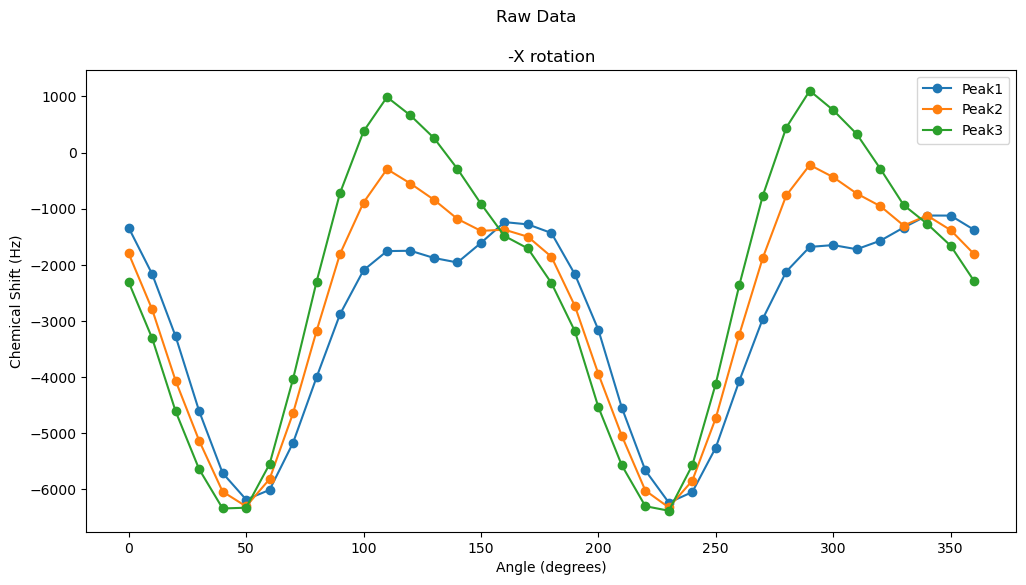

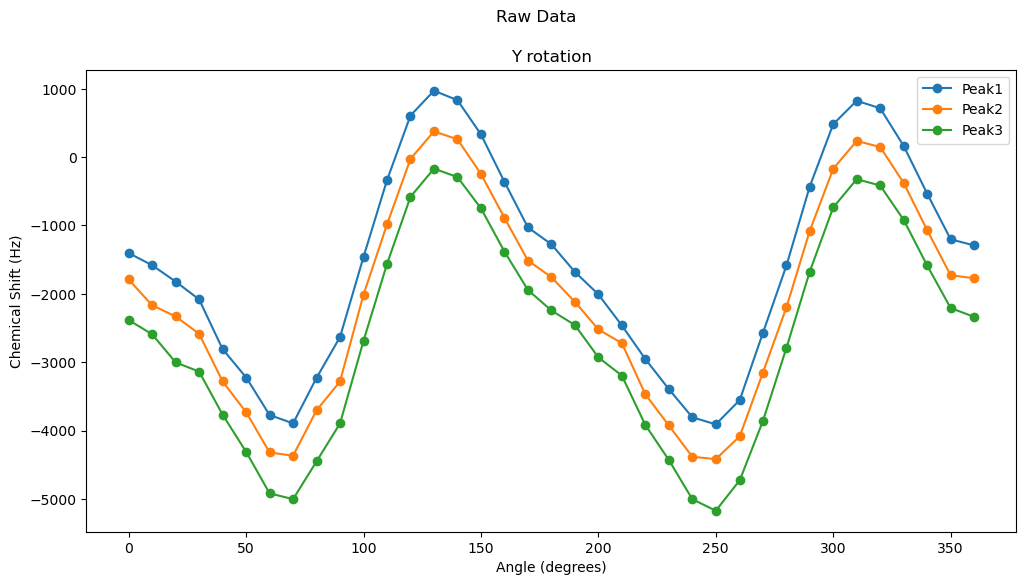

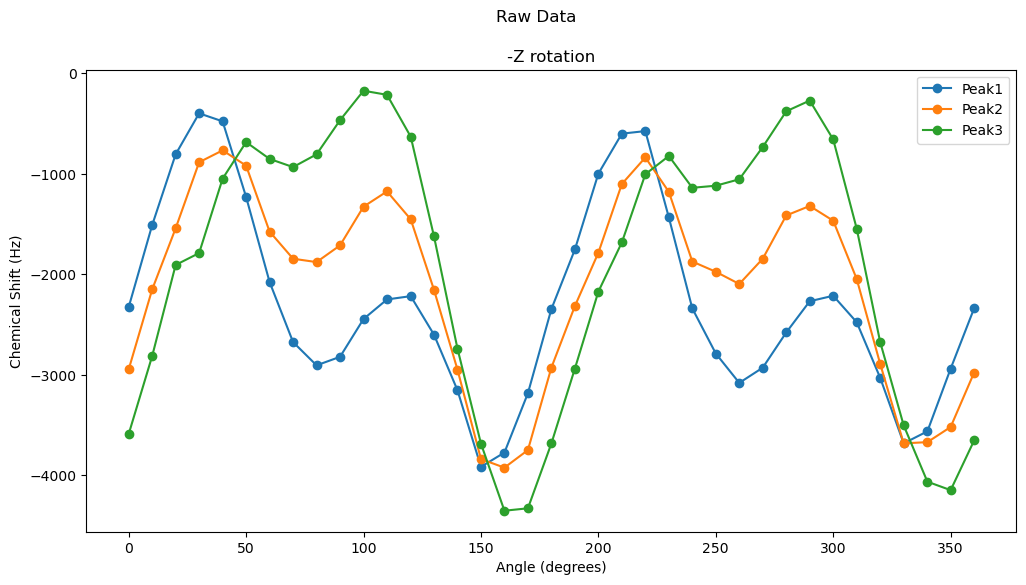

In [2]:
titles = ['-X rotation', 'Y rotation', '-Z rotation']
df = [0]*3

    
df[0] = pd.read_excel('//home/shiva/WMU/PhD/Scripts/phd_project/Python/NMR/Data_exp/B_Rotation_Plot.xlsx', sheet_name='(+)8HQ_X_Rot', skiprows=[1])
df[1] = pd.read_excel('//home/shiva/WMU/PhD/Scripts/phd_project/Python/NMR/Data_exp/B_Rotation_Plot.xlsx', sheet_name='(+)8HQ_Y_Rot', skiprows=[1])
df[2] = pd.read_excel('//home/shiva/WMU/PhD/Scripts/phd_project/Python/NMR/Data_exp/B_Rotation_Plot.xlsx', sheet_name='(+)8HQ_Z_Rot', skiprows=[1])
for i in range(3):

    df[i].Cluster1Peak0 = df[i].Cluster1Peak0*w0
    df[i].Cluster1Peak1 = df[i].Cluster1Peak1*w0
    df[i].Cluster1Peak2 = df[i].Cluster1Peak2*w0

    # print(df[i].Cluster1Peak1)
    plt.figure(figsize=(12, 6))
    plt.plot(df[i].Angle, df[i].Cluster1Peak0, label = 'Peak1', marker='o')
    plt.plot(df[i].Angle, df[i].Cluster1Peak1, label = 'Peak2', marker='o')
    plt.plot(df[i].Angle, df[i].Cluster1Peak2, label = 'Peak3', marker='o')
    plt.suptitle('Raw Data')
    plt.xlabel('Angle (degrees)')
    plt.ylabel('Chemical Shift (Hz)')
    plt.title(titles[i])
    plt.legend()
    plt.show()

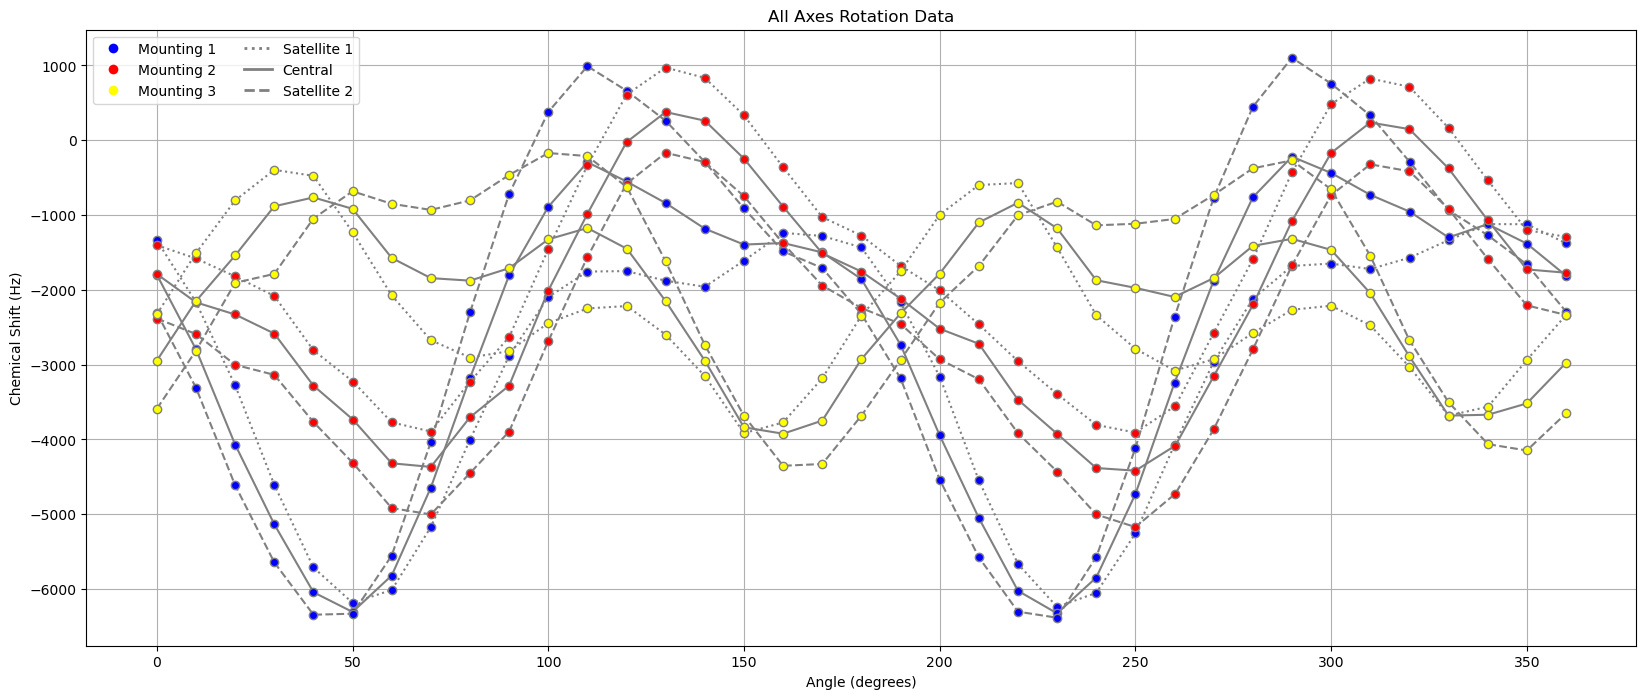

In [17]:
plt.figure(figsize = (20,8), dpi = 100)

plt.plot(df[0].Angle, df[0].Cluster1Peak0,linestyle='dotted', marker='o', color = 'grey', markerfacecolor = 'blue')
plt.plot(df[0].Angle, df[0].Cluster1Peak1,linestyle='-', marker='o', color = 'grey', markerfacecolor = 'blue')
plt.plot(df[0].Angle, df[0].Cluster1Peak2, linestyle='--', marker='o', color = 'grey', markerfacecolor  = 'blue')

plt.plot(df[1].Angle, df[1].Cluster1Peak0,linestyle='dotted', marker='o', color = 'grey', markerfacecolor  = 'red')
plt.plot(df[1].Angle, df[1].Cluster1Peak1,linestyle='-', marker='o', color = 'grey', markerfacecolor  = 'red')
plt.plot(df[1].Angle, df[1].Cluster1Peak2, linestyle='--', marker='o', color = 'grey', markerfacecolor  = 'red')

plt.plot(df[2].Angle, df[2].Cluster1Peak0, linestyle='dotted', marker='o', color = 'grey', markerfacecolor  = 'yellow')
plt.plot(df[2].Angle, df[2].Cluster1Peak1, linestyle='-', marker='o', color = 'grey', markerfacecolor  = 'yellow')
plt.plot(df[2].Angle, df[2].Cluster1Peak2, linestyle='--', marker='o', color = 'grey', markerfacecolor  = 'yellow')

# Custom legend handle ( markers)
marker_legend = [Line2D([0], [0], marker='o', color='w', markerfacecolor='blue', markersize=8, label='Mounting 1'),
                 Line2D([0], [0], marker='o', color='w', markerfacecolor='red', markersize=8, label='Mounting 2'),
                 Line2D([0], [0], marker='o', color='w', markerfacecolor='yellow', markersize=8, label='Mounting 3')]

# Custom legend for lines
line_legend = [Line2D([0], [0], color='grey', lw=2,linestyle='dotted', label='Satellite 1'),
               Line2D([0], [0], color='grey', lw=2,linestyle='-', label='Central'), 
               Line2D([0], [0], color='grey', lw=2,linestyle='--', label='Satellite 2')]

# # Add line legend
# legend1 = plt.legend(handles=line_legend, loc='upper left')

# # Add marker legend separately
# legend2 = plt.legend(handles=marker_legend, loc='lower right', title="Marker Legend")

# # Add the first legend back to the plot after adding the second legend
# plt.gca().add_artist(legend1)

# Combine both markers and lines into a single list for the legend
combined_legend = marker_legend + line_legend
# Add a single legend with both markers and lines, placed side by side
plt.legend(handles=combined_legend, loc='upper left', bbox_to_anchor=(0, 1), ncol=2)



plt.title('All Axes Rotation Data')
plt.xlabel('Angle (degrees)')
plt.ylabel('Chemical Shift (Hz)')
plt.grid()
plt.show()

In [4]:
freq_sum = [0]*3
freq_diff = [0]*3
for i in range(3):

    freq_sum[i] = df[i].Cluster1Peak0 + df[i].Cluster1Peak1 + df[i].Cluster1Peak2
    freq_diff[i] = df[i].Cluster1Peak0 - df[i].Cluster1Peak2

    # print(freq_sum[i])
# plt.plot(df[i].Angle, freq_sum)
# plt.show()
# plt.plot(df[i].Angle, freq_diff)

R squared: 0.9991313722438313
┌───┬───────────────────────────────────────────────────┐
│   │         a         b         c         d         e │
├───┼───────────────────────────────────────────────────┤
│ a │         1   -0.0359  -3.6e-05   -0.0359   0.00026 │
│ b │   -0.0359         1   0.00017   -0.0511  0.000132 │
│ c │  -3.6e-05   0.00017         1  0.000152 -0.000347 │
│ d │   -0.0359   -0.0511  0.000152         1 -0.000304 │
│ e │   0.00026  0.000132 -0.000347 -0.000304         1 │
└───┴───────────────────────────────────────────────────┘
Chi square: 1142509.7657963822
┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 1.143e+06 (chi2/ndof = 35703.4)│              Nfcn = 151              │
│ EDM = 1.49e-18 (Goal: 0.0002)    │                                      │
├────────────────────────────────

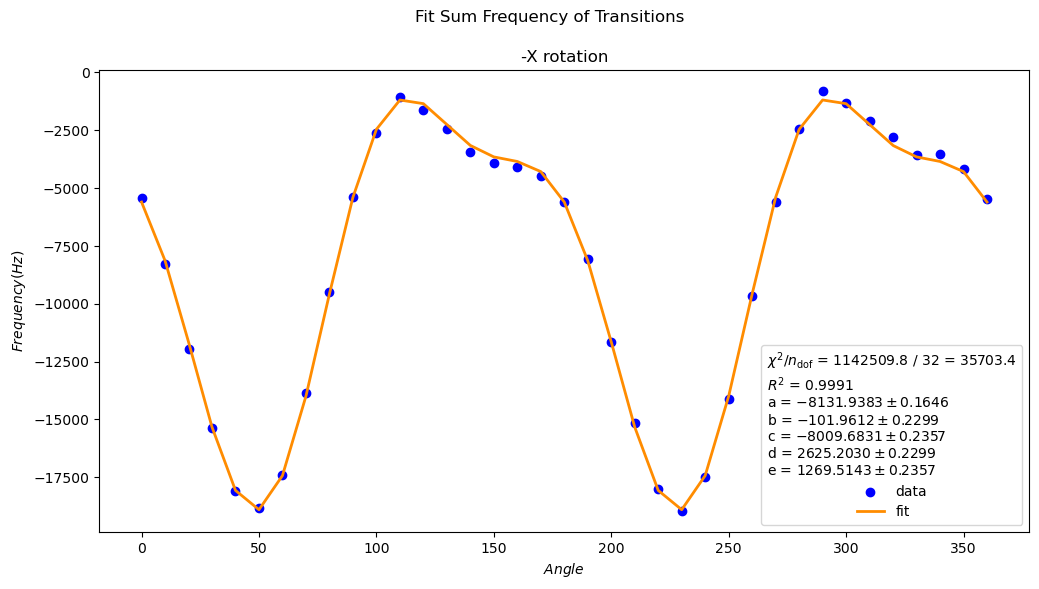

a = -8131.938322116182
b = -101.96115128182171
c = -8009.683133530539
d = 2625.203015631615
e = 1269.51428700384
R squared: 0.9959353751084086
┌───┬───────────────────────────────────────────────────┐
│   │         a         b         c         d         e │
├───┼───────────────────────────────────────────────────┤
│ a │         1   -0.0356  0.000415   -0.0361 -0.000373 │
│ b │   -0.0356         1 -0.000273   -0.0512  0.000608 │
│ c │  0.000415 -0.000273         1  1.42e-06  0.000131 │
│ d │   -0.0361   -0.0512  1.42e-06         1 -0.000509 │
│ e │ -0.000373  0.000608  0.000131 -0.000509         1 │
└───┴───────────────────────────────────────────────────┘
Chi square: 3074412.418149458
┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 3.074e+06 (chi2/ndof = 96075.4)│              Nfcn = 131             

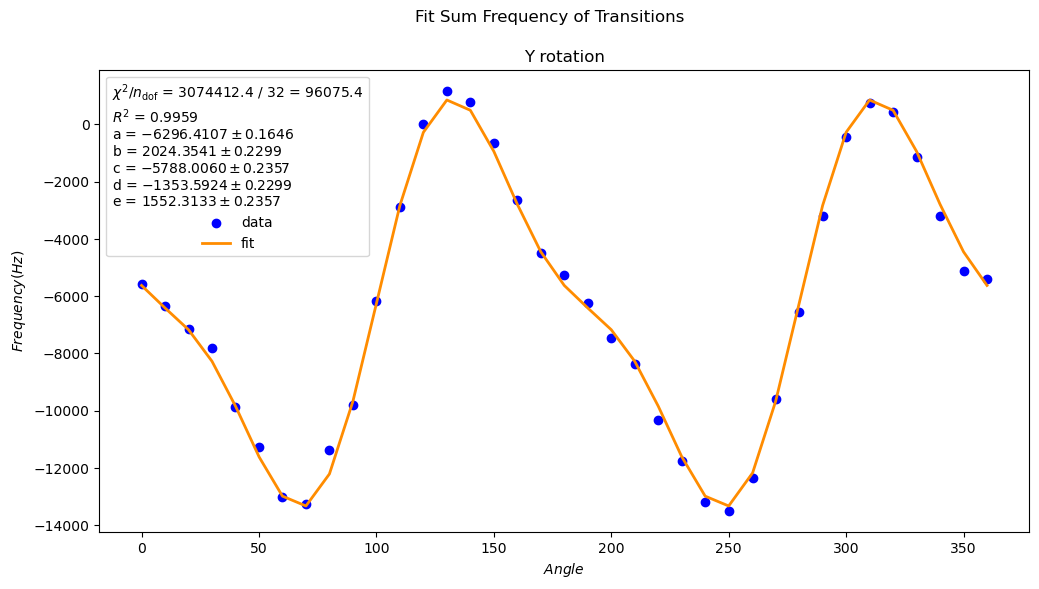

a = -6296.410721977398
b = 2024.3540837999496
c = -5788.006015151562
d = -1353.592383758633
e = 1552.3132667016732
R squared: 0.9843138508019773
┌───┬───────────────────────────────────────────────────┐
│   │         a         b         c         d         e │
├───┼───────────────────────────────────────────────────┤
│ a │         1    -0.036 -3.44e-05   -0.0358   7.5e-05 │
│ b │    -0.036         1   6.9e-05   -0.0516   -0.0002 │
│ c │ -3.44e-05   6.9e-05         1  -0.00012  0.000105 │
│ d │   -0.0358   -0.0516  -0.00012         1  0.000547 │
│ e │   7.5e-05   -0.0002  0.000105  0.000547         1 │
└───┴───────────────────────────────────────────────────┘
Chi square: 4642762.756223639
┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 4.643e+06 (chi2/ndof = 145086.3)│              Nfcn = 151          

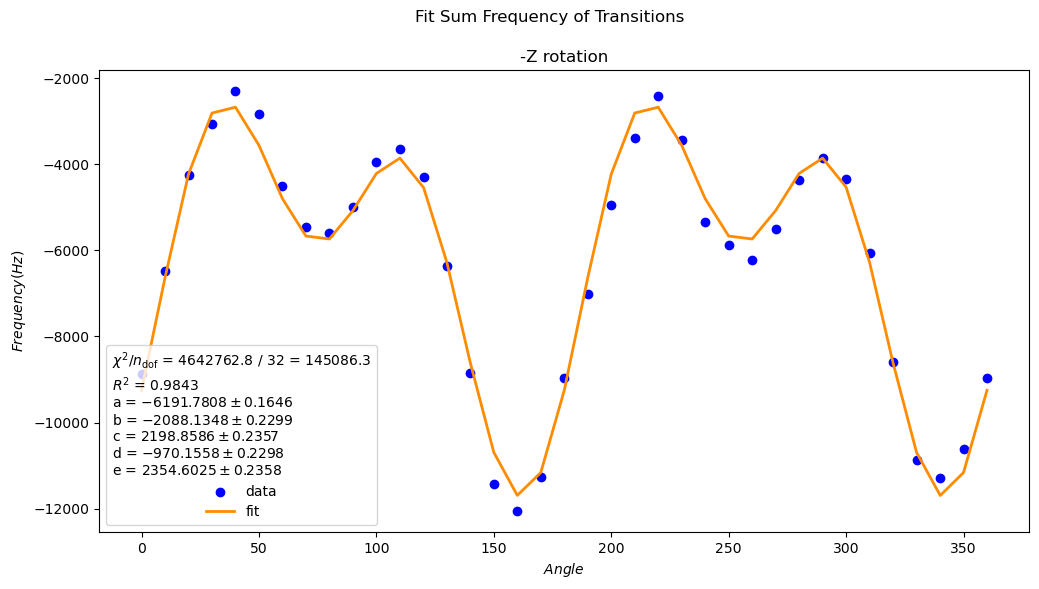

a = -6191.780762900476
b = -2088.1348265491
c = 2198.8585787655456
d = -970.155834370666
e = 2354.6025270595214


In [5]:
m_s = [0]*3
corr_mat = [0]*3

for i in range(3):
    least_squares = LeastSquares(df[i].Angle, freq_sum[i], 1, fourier5)
    
    m_s[i] = Minuit(least_squares, a = 1, b = 1, c= 1, d = 0, e = 1).migrad()


    m_s[i].migrad()  # finds minimum of least_squares function
    m_s[i].hesse()   # accurately computes uncertainties
    
    fit_info = [
    f"$\\chi^2$/$n_\\mathrm{{dof}}$ = {m_s[i].fval:.1f} / {m_s[i].ndof:.0f} = {m_s[i].fmin.reduced_chi2:.1f}",
    ]
    # print(fit_info)
    # Calculate R squared
    y_true = freq_sum[i]
    y_pred = fourier5(df[i].Angle, *m_s[i].values)
    SST = np.sum((y_true - np.mean(y_true))**2)
    SSR = np.sum((y_true - y_pred)**2)
    R_squared = 1 - (SSR / SST)
    print(f"R squared: {R_squared}")

        # Append R squared to fit_info
    fit_info.append(f"$R^2$ = {R_squared:.4f}")
    
    for p, v, e in zip(m_s[i].parameters, m_s[i].values, m_s[i].errors):
        fit_info.append(f"{p} = ${v:.4f} \\pm {e:.4f}$")

    corr_mat = (m_s[i].covariance.correlation())
    print(corr_mat)
    print('Chi square:', m_s[i].fval)
    print(m_s[i].migrad())


    # draw data and fitted line

    plt.figure(figsize=(12, 6))
    plt.scatter(df[i].Angle, freq_sum[i], label="data", color = 'blue')
    plt.plot(df[i].Angle, fourier5(df[i].Angle, *m_s[i].values), label="fit", lw = 2, color = 'darkorange')
    plt.xlabel(r'$Angle$')
    plt.ylabel(r'$Frequency (Hz)$')
    # Titles
    plt.suptitle('Fit Sum Frequency of Transitions')
    plt.title(titles[i])
    plt.legend(title="\n".join(fit_info))
    # plt.grid()
    plt.show()
    
    for key, value in zip(m_s[i].parameters, m_s[i].values):
        print(f"{key} = {value}")

R squared: 0.9908201042245346


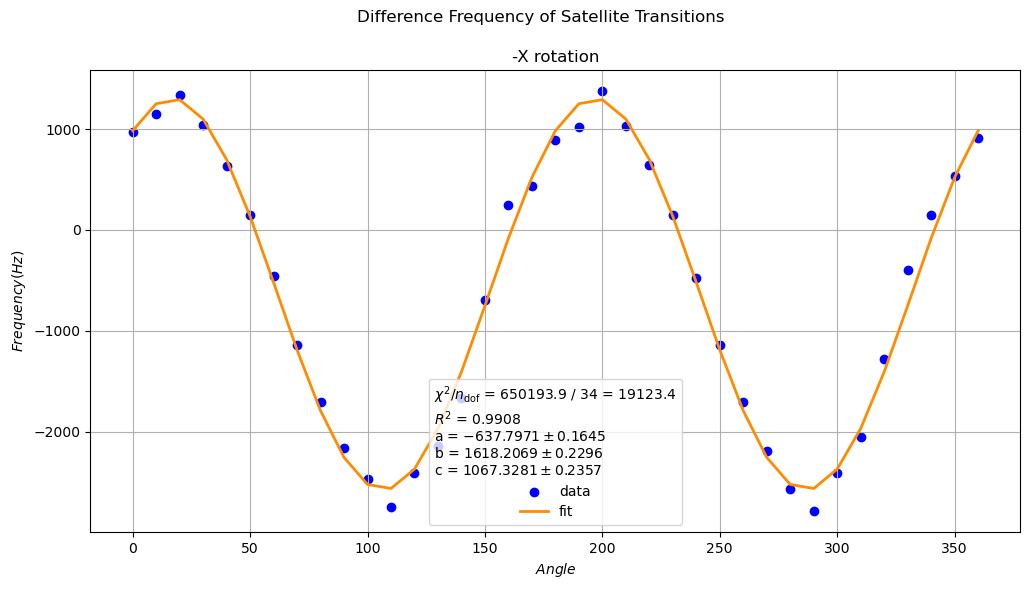

a = -637.7971451475952
b = 1618.2069015086242
c = 1067.3280928570089
R squared: 0.675175561033923


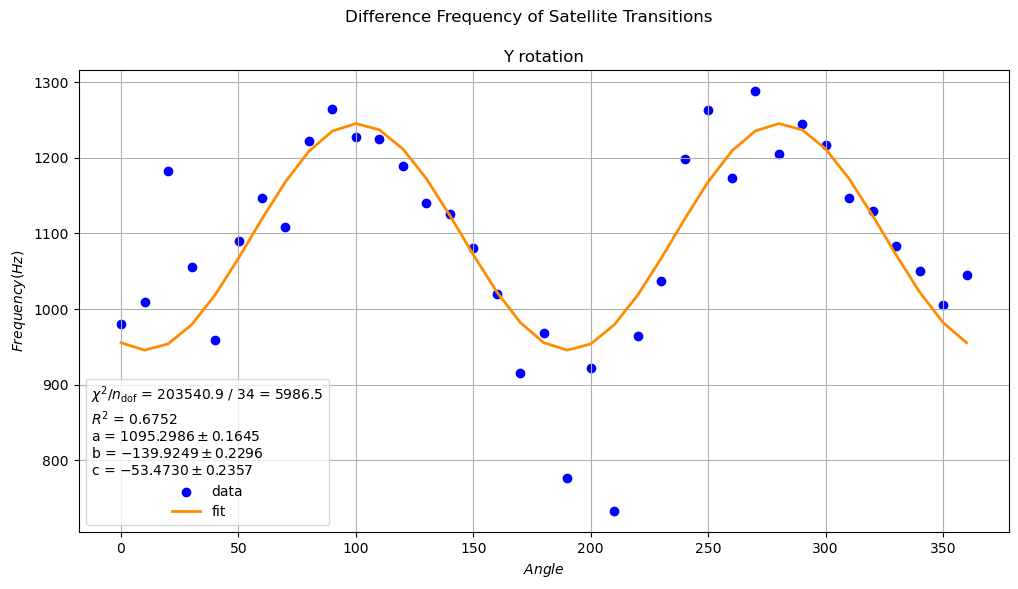

a = 1095.298601292924
b = -139.92493739837244
c = -53.47296667356892
R squared: 0.9804947792235532


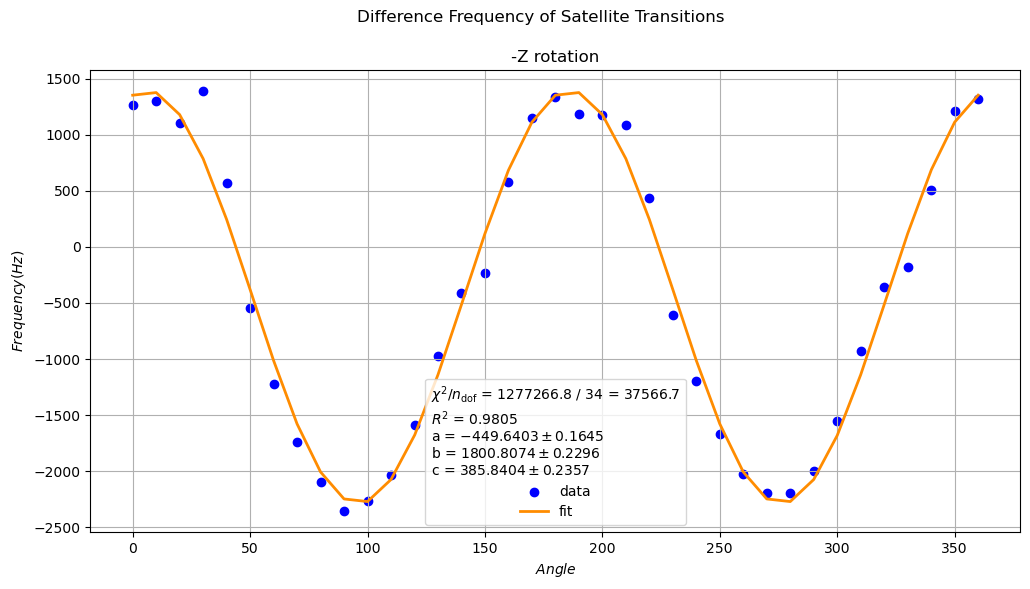

a = -449.6402551059898
b = 1800.807431905332
c = 385.8404419585922


In [6]:
m_d = [0]*3

for i in range(3):
    least_squares = LeastSquares(df[i].Angle, freq_diff[i], 1,fourier3)
    m_d[i] = Minuit(least_squares, a = 1, b = 1, c= 1)
    m_d[i].migrad()  # finds minimum of least_squares function
    m_d[i].hesse()   # accurately computes uncertainties
    fit_info = [
    f"$\\chi^2$/$n_\\mathrm{{dof}}$ = {m_d[i].fval:.1f} / {m_d[i].ndof:.0f} = {m_d[i].fmin.reduced_chi2:.1f}",
    ]
    # print(fit_info)
    
    # Calculate R squared
    y_true = freq_diff[i]
    y_pred = fourier3(df[i].Angle, *m_d[i].values)
    SST = np.sum((y_true - np.mean(y_true))**2)
    SSR = np.sum((y_true - y_pred)**2)
    R_squared = 1 - (SSR / SST)
    print(f"R squared: {R_squared}")

    # plt.imshow(corr_mat, cmap='coolwarm')
    
        # Append R squared to fit_info
    fit_info.append(f"$R^2$ = {R_squared:.4f}")

    for p, v, e in zip(m_d[i].parameters, m_d[i].values, m_d[i].errors):
        fit_info.append(f"{p} = ${v:.4f} \\pm {e:.4f}$")

    corr_mat = (m_d[i].covariance.correlation())

    
    # draw data and fitted line
    plt.figure(figsize=(12, 6))
    plt.scatter(df[i].Angle, freq_diff[i], label="data", color = 'blue')
    plt.plot(df[i].Angle, fourier3(df[i].Angle, *m_d[i].values), label="fit", lw = 2, color = 'darkorange')
    # plt.plot(df[i].angle, HQ1[i], label = 'input ')
    plt.xlabel(r'$Angle$')
    plt.ylabel(r'$Frequency (Hz)$')
    # Title
    plt.suptitle('Difference Frequency of Satellite Transitions')
    plt.title(titles[i])
    plt.legend(title="\n".join(fit_info))
    plt.grid()
    plt.show()
    
    for key, value in zip(m_d[i].parameters, m_d[i].values):
        print(f"{key} = {value}")

**Find HQ Tensor**

In [7]:
a_s = [0]*3; a_d = [0]*3
b_s = [0]*3; b_d = [0]*3
c_s = [0]*3; c_d = [0]*3
d_s = [0]*3
e_s = [0]*3

par_s = [a_s, b_s, c_s, d_s, e_s]
par_d = [a_d, b_d, c_d]

for i in range(0,3):
    for k in range(len(par_s)):
        par_s[k][i] = m_s[i].values[k]
    for j in range(len(par_d)):
        par_d[j][i] = m_d[i].values[j]
# Quadrupolar coefficients
A_Q = [0]*3
B_Q = [0]*3
C_Q = [0]*3

A_HQ1 = [0]*3
B_HQ1 = [0]*3
X = [0]*3
# https://stackoverflow.com/questions/36354807/solving-linear-equations-w-three-variables-using-numpy

for i in range(0,3):
    A_HQ1[i] = np.array([[1/2, 1/2], [1/2, -1/2]])
    B_HQ1[i] = np.array([a_d[i], b_d[i]])
    X[i] = np.linalg.inv(A_HQ1[i]).dot(B_HQ1[i])

# gzz_q1 = X[0][0]
# gyy_q1= X[0][1]
gyz_q = -c_d[0]

# gzz_q2 = X[1][0]
# gxx_q2 = X[1][1]
gxz_q = c_d[1]

# gxx_q3 = X[2][0]
# gyy_q3 = X[2][1]
gxy_q = -c_d[2]

gzz_q1 = (2*a_d[0] + 2*b_d[0])/2
gyy_q1 = (2*a_d[0] - 2*b_d[0])/2

gzz_q2 = (2*a_d[1] + 2*b_d[1])/2
gxx_q2 = (2*a_d[1] - 2*b_d[1])/2

gxx_q3 = (2*a_d[2] + 2*b_d[2])/2
gyy_q3 = (2*a_d[2] - 2*b_d[2])/2

gxx_q = np.mean([gxx_q2, gxx_q3])
gyy_q = np.mean([gyy_q1, gyy_q3])
gzz_q = np.mean([gzz_q1, gzz_q2])




QXG_f = np.zeros((3, 3))                                #Tensor from fitting
QXG_f[0,0]=gxx_q; QXG_f[0,1]=gxy_q; QXG_f[0,2]=gxz_q;
QXG_f[1,0]=gxy_q; QXG_f[1,1]=gyy_q; QXG_f[1,2]=gyz_q;
QXG_f[2,0]=gxz_q; QXG_f[2,1]=gyz_q; QXG_f[2,2]=gzz_q;

   #Plot to check that difference frequency is mostly HQ1
#    plt.plot(df[i].angle, HQ1[i], label = 'HQ1')
#    plt.plot(df[i].angle, df[i].freq_diff, label = 'diff frequency')
#    plt.legend()
#    plt.show()

print(gxx_q2, gxx_q3, gyy_q1, gyy_q3, gzz_q1, gzz_q2)
print('Calculated Quad Tensor:\n',QXG_f)



1235.2235386912967 1351.167176799342 -2256.0040466562195 -2250.4476870113217 980.409756361029 955.3736638945517
Calculated Quad Tensor:
 [[ 1293.19535775  -385.84044196   -53.47296667]
 [ -385.84044196 -2253.22586683 -1067.32809286]
 [  -53.47296667 -1067.32809286   967.89171013]]


In [8]:
# A = np.array([gzz_q + gyy_q, gzz_q + gxx_q, gxx_q + gyy_q])*1/2
# B = np.array([gzz_q - gyy_q, gzz_q - gxx_q, gxx_q - gyy_q ])*1/2
# C = np.array([-gyz_q, gxz_q, -gxy_q])

# HQ1= [0]*3

# for i in range(3):
#    HQ1[i] = a_d[i] + b_d[i]*np.cos(2*df[i].Angle*np.pi/180.) + c_d[i]*np.cos(2*df[i].Angle*np.pi/180.) 

#    #Plot to check that difference frequency is mostly HQ1
#    plt.plot(df[i].Angle, HQ1[i], label = 'HQ1')
#    plt.plot(df[i].Angle, freq_diff[i], label = 'diff frequency')
#    plt.legend()
#    plt.show()

**Find HQ1 and HQ2**

In [9]:
HQ1_freq_3212 = [0]*3
HQ1_freq_1212 = [0]*3
HQ1_freq_1232 = [0]*3


HQ2_freq_3212 = [0]*3
HQ2_freq_1212 = [0]*3
HQ2_freq_1232 = [0]*3

for i in range (3):
    ang = df[i].Angle*np.pi/180.
    atheta = [-ang, ang,np.pi/2 ] #-x, y, -z rotation
    aphi = [np.pi/2, 0, -ang]

    theta = atheta[i] 
    phi = aphi[i]
    ct = np.cos(theta); st = np.sin(theta); s2t = 2*ct*st; c2t = ct*ct-st*st;
    cp = np.cos(phi); sp = np.sin(phi); s2p = 2*cp*sp; c2p = cp*cp-sp*sp;

    R2m2Q, R2m1Q, R20Q, R2p1Q, R2p2Q = Quad(QXG_f,ct, st, s2t, c2t, cp ,sp ,c2p ,s2p)

            
    HQ1 = 1/(2*Ispin*(2*Ispin-1))*R20Q
    HQ2a= (0.5/(2*Ispin*(2*Ispin-1))**2)*(R2m2Q*R2p2Q)/wX                         
    HQ2b = (0.5/(2*Ispin*(2*Ispin-1))**2)*(R2m1Q*R2p1Q)/wX


    HQ1_freq_3212[i] = 6*(np.real(HQ1))               # 3/2 <-> 1/2
    HQ1_freq_1212[i] = 0*(np.real(HQ1))               # 1/2 <-> -1/2
    HQ1_freq_1232[i] = -6*(np.real(HQ1))              #-1/2   <-> -3/2       
    
    HQ2_freq_3212[i] = 0*np.real(HQ2a) + -12*np.real(HQ2b)       # 3/2 <-> 1/2
    HQ2_freq_1212[i] = 6*np.real(HQ2a) + 12*np.real(HQ2b)        # 1/2 <-> -1/2
    HQ2_freq_1232[i] = 0*np.real(HQ2a) + -12*np.real(HQ2b)       #-1/2   <-> -3/2                                                                          


# len(HQ_freq_3212[0])
# len(df[0].freq_3212)

# print(HQ_freq_3212[0])

# HQ1_3212 = 1/4*(gzz_q + gxx_q + (gzz_q - gxx_q)*np.cos(2*df[i].angle*np.pi/180.) + 2*gxz_q*np.cos(2*df[i].angle*np.pi/180.))
# HQ1_1212 = 0
# HQ1_1232 = -1/4*(gzz_q + gxx_q + (gzz_q - gxx_q)*np.cos(2*df[i].angle*np.pi/180.) + 2*gxz_q*np.cos(2*df[i].angle*np.pi/180.))

**Verify Tensor Components from HQ2**

In [10]:
Dx = (-21/16*(gzz_q - gyy_q)**2 + 21/4*gyz_q**2)/(72*wX)
Ex = 21/4*(gzz_q - gyy_q)*gyz_q/(72*wX)

Dy = (-21/16*(gzz_q - gxx_q)**2 + 21/4*gxz_q**2)/(72*wX)
Ey = (-21/4*gxz_q*(gzz_q - gxx_q))/(72*wX)

Dz = (-21/16*(gxx_q - gyy_q)**2 + 21/4*gxy_q**2)/(72*wX)
Ez = (21/4*gxy_q*(gxx_q - gyy_q))/(72*wX)

table = [['Dx', d_s[0], Dx],  ['Ex', e_s[0], Ex],['Dy', d_s[1], Dy],  ['Ey', e_s[1], Ey], ['Dz', d_s[2], Dz],  ['Ez', e_s[2], Ez]]
print(tabulate(table, headers=['Coefficient','Coefficients from fit', 'Calculated coefficients']))

Coefficient      Coefficients from fit    Calculated coefficients
-------------  -----------------------  -------------------------
Dx                            2625.2                 -0.000550884
Ex                            1269.51                -0.00130193
Dy                           -1353.59                -8.93566e-06
Ey                            1552.31                -6.58729e-06
Dz                            -970.156               -0.00113433
Ez                            2354.6                 -0.000518181


**Find CSA Tensor**

R squared: 0.8779147391970695
┌───┬───────────────────────────────┐
│   │         a         b         c │
├───┼───────────────────────────────┤
│ a │         1   -0.0378 -3.04e-05 │
│ b │   -0.0378         1  0.000178 │
│ c │ -3.04e-05  0.000178         1 │
└───┴───────────────────────────────┘
┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 1.606e+08 (chi2/ndof = 4722920.3)│              Nfcn = 85               │
│ EDM = 6.82e-11 (Goal: 0.0002)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │        No Parameters at limit        │
├──────────────────────────────────┼──────────────────────────────────────┤
│ Below EDM threshold (goal x 10)  │           Below call limit           │
├─────────────

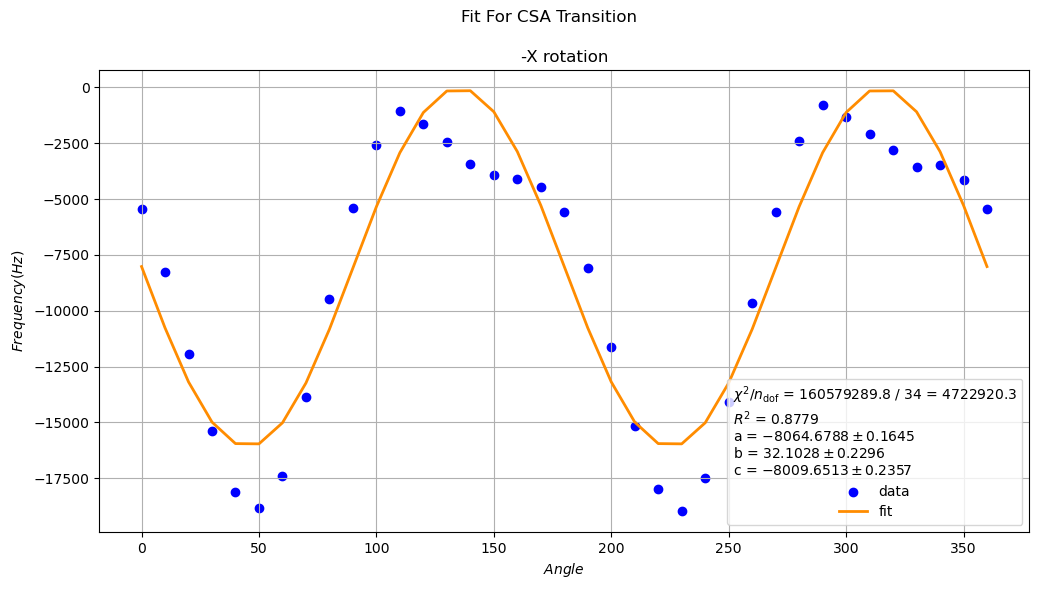

a = -8064.678783546267
b = 32.10278796715055
c = -8009.651344977534
R squared: 0.8928073890728936
┌───┬───────────────────────────────┐
│   │         a         b         c │
├───┼───────────────────────────────┤
│ a │         1   -0.0375  0.000415 │
│ b │   -0.0375         1 -0.000273 │
│ c │  0.000415 -0.000273         1 │
└───┴───────────────────────────────┘
┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 8.108e+07 (chi2/ndof = 2384666.2)│              Nfcn = 93               │
│ EDM = 4.42e-18 (Goal: 0.0002)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │        No Parameters at limit        │
├──────────────────────────────────┼──────────────────────────────────────┤
│ Below EDM threshold 

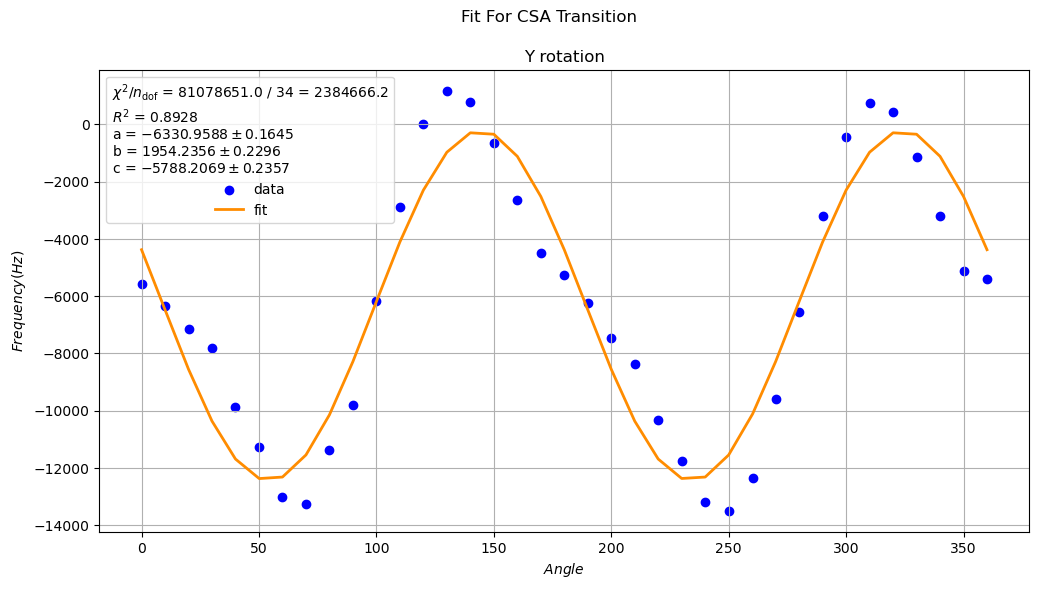

a = -6330.958826224481
b = 1954.2356036447422
c = -5788.206931834692
R squared: 0.5869490139692866
┌───┬───────────────────────────────┐
│   │         a         b         c │
├───┼───────────────────────────────┤
│ a │         1   -0.0379 -3.87e-05 │
│ b │   -0.0379         1   6.3e-05 │
│ c │ -3.87e-05   6.3e-05         1 │
└───┴───────────────────────────────┘
┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 1.223e+08 (chi2/ndof = 3595712.2)│              Nfcn = 87               │
│ EDM = 1.94e-16 (Goal: 0.0002)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │        No Parameters at limit        │
├──────────────────────────────────┼──────────────────────────────────────┤
│ Below EDM threshold

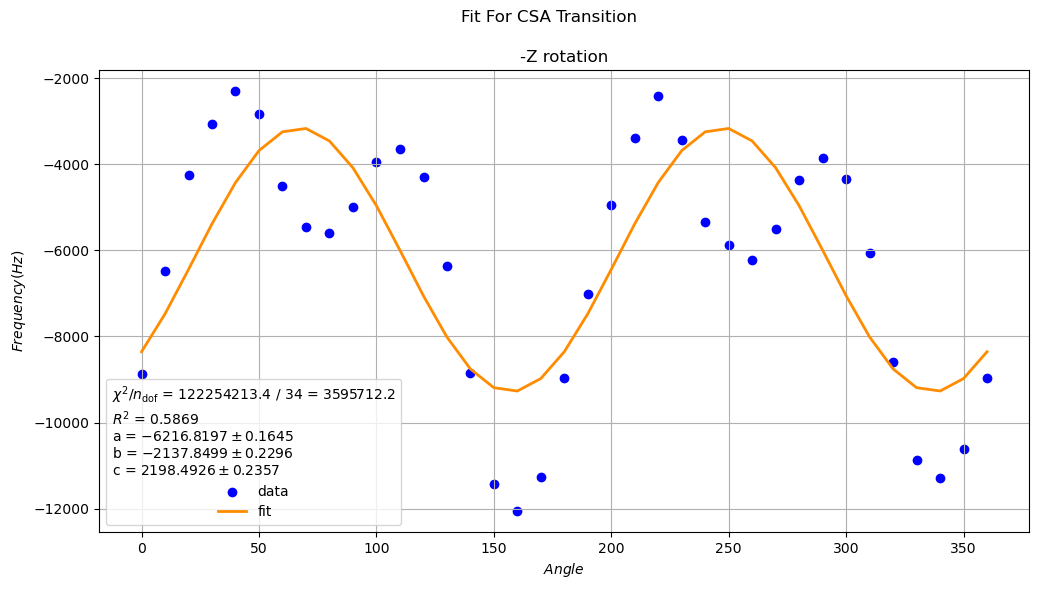

a = -6216.819762428554
b = -2137.849956855706
c = 2198.4925386233767


In [11]:
HQ2_freq_sum = [0]*3
csa = [0]*3

for i in range(3):
    HQ2_freq_sum[i] = HQ2_freq_3212[i] + HQ2_freq_1212[i] + HQ2_freq_1232[i]
    csa[i] = freq_sum[i] - HQ2_freq_sum[i]



m_csa = [0]*3

# 
for i in range(0,3):

    least_squares = LeastSquares(df[i].Angle, csa[i], 1,fourier3)
    
    m_csa[i] = Minuit(least_squares, a = -1, b = -1, c= -1)
   

    m_csa[i].migrad()  # finds minimum of least_squares function
    m_csa[i].hesse()   # accurately computes uncertainties
    fit_info = [
    f"$\\chi^2$/$n_\\mathrm{{dof}}$ = {m_csa[i].fval:.1f} / {m_csa[i].ndof:.0f} = {m_csa[i].fmin.reduced_chi2:.1f}",
    ]
   

     # Calculate R squared
    y_true = csa[i]
    y_pred = fourier3(df[i].Angle, *m_csa[i].values)
    SST = np.sum((y_true - np.mean(y_true))**2)
    SSR = np.sum((y_true - y_pred)**2)
    R_squared = 1 - (SSR / SST)
    print(f"R squared: {R_squared}")

    
    # Append R squared to fit_info
    fit_info.append(f"$R^2$ = {R_squared:.4f}")

    for p, v, e in zip(m_csa[i].parameters, m_csa[i].values, m_csa[i].errors):
        fit_info.append(f"{p} = ${v:.4f} \\pm {e:.4f}$")

    corr_mat = (m_csa[i].covariance.correlation())
    print(corr_mat)
    print(m_csa[i].migrad())
    
   
    
    # draw data and fitted line
    plt.figure(figsize=(12, 6))
    plt.scatter(df[i].Angle, csa[i], label="data", color = 'blue')
    plt.plot(df[i].Angle, fourier3(df[i].Angle, *m_csa[i].values), label="fit", lw = 2, color = 'darkorange')
    plt.xlabel(r'$Angle$')
    plt.ylabel(r'$Frequency (Hz)$')
    # Title
    plt.suptitle('Fit For CSA Transition')
    plt.title(titles[i])
    plt.legend(title="\n".join(fit_info))
    plt.grid()
    plt.show()
    
    for key, value in zip(m_csa[i].parameters, m_csa[i].values):
        print(f"{key} = {value}")

a_csa = [0]*3; 
b_csa = [0]*3; 
c_csa = [0]*3; 

par_csa = [a_csa, b_csa, c_csa]

for i in range(0,3):
    for k in range(len(par_csa)):
        par_csa[k][i] = m_csa[i].values[k]


In [12]:
A= [0]*3
B = [0]*3
C = [0]*3
A_HCSA1 = [0]*3
B_HCSA1 = [0]*3
X = [0]*3


for i in range(0,3):

    A_HCSA1[i] = np.array([[3/2, 3/2], [3/2, -3/2]])
    B_HCSA1[i] = np.array([a_csa[i], b_csa[i]])
    X[i] = np.linalg.inv(A_HCSA1[i]).dot(B_HCSA1[i])
    

gzz_csa1 = X[0][0]
gyy_csa1= X[0][1]
gyz_csa = -c_csa[0]/3

gzz_csa2 = X[1][0]
gxx_csa2 = X[1][1]
gxz_csa = c_csa[1]/3

gxx_csa3 = X[2][0]
gyy_csa3 = X[2][1]
gxy_csa = -c_csa[2]/3

gxx_csa = np.mean([gxx_csa2, gxx_csa3])
gyy_csa = np.mean([gyy_csa1, gyy_csa3])
gzz_csa = np.mean([gzz_csa1, gzz_csa2])




CsaQXG_f = np.zeros((3, 3))                                #Tensor from fitting
CsaQXG_f[0,0]=gxx_csa; CsaQXG_f[0,1]=gxy_csa; CsaQXG_f[0,2]=gxz_csa;
CsaQXG_f[1,0]=gxy_csa; CsaQXG_f[1,1]=gyy_csa; CsaQXG_f[1,2]=gyz_csa;
CsaQXG_f[2,0]=gxz_csa; CsaQXG_f[2,1]=gyz_csa; CsaQXG_f[2,2]=gzz_csa;


print(gxx_csa2, gxx_csa3, gyy_csa1, gyy_csa3, gzz_csa1, gzz_csa2)
print('Calculated CSA Tensor:\n',CsaQXG_f)



print(tabulate([['gxx_q',gxx_q], ['gyy_q',gyy_q], ['gzz_q',gzz_q], ['gxy_q',gxy_q], ['gyz_q',gyz_q], ['gxz_q',gxz_q],['gxx_csa',gxx_csa], ['gyy_csa',gyy_csa], ['gzz_csa',gzz_csa], ['gxy_csa',gxy_csa], ['gyz_csa',gyz_csa], ['gxz_csa',gxz_csa]]))

-2761.7314766230743 -2784.8899064280863 -2698.9271905044725 -1359.656601857616 -2677.5253318597056 -1458.9077408599126
Calculated CSA Tensor:
 [[-2773.31069153  -732.83084621 -1929.40231061]
 [ -732.83084621 -2029.29189618  2669.88378166]
 [-1929.40231061  2669.88378166 -2068.21653636]]
-------  ---------
gxx_q     1293.2
gyy_q    -2253.23
gzz_q      967.892
gxy_q     -385.84
gyz_q    -1067.33
gxz_q      -53.473
gxx_csa  -2773.31
gyy_csa  -2029.29
gzz_csa  -2068.22
gxy_csa   -732.831
gyz_csa   2669.88
gxz_csa  -1929.4
-------  ---------


In [13]:
eigenvalues, eigenvectors = np.linalg.eig(QXG_f)
D_quad = np.diag(eigenvalues)
print('Diagonalized Quadrupolar Tensor:\n', D_quad)
sorted_eigenvalues = sorted(eigenvalues, key=abs)


print('Sorted Eigenvalues of Quadrupolar diagonal matrix:\n', sorted_eigenvalues) #See Haberlen convention for details [ref: Single-Crystal NMR Spectroscopy – Method Development and Application to Inorganic Solids]

Gzz_q = sorted_eigenvalues[2]
Gyy_q = sorted_eigenvalues[1]
Gxx_q = sorted_eigenvalues[0]

print('Quad Tensors Gzz_q, Gyy_q, Gxx_q (According to |Qzz| >= |Qyy| >= |Qxx|): \n', Gzz_q, Gyy_q, Gxx_q)

print('================================================================================================')

eigenvalues, eigenvectors = np.linalg.eig(CsaQXG_f)
D_csa = np.diag(eigenvalues)

print('Diagonalized CSA Tensor:\n',D_csa)
csa_avg = np.mean(eigenvalues)

sorted_eigenvalues = sorted((eigenvalues - csa_avg), key = abs) #See Haberlen convention for details

print('Sorted Eigenvalues (Eigenvalue + isotropic CS)  of CSA diagonal matrix:\n',sorted_eigenvalues )

Gzz_csa = sorted_eigenvalues[2] + csa_avg
Gxx_csa = sorted_eigenvalues[1] + csa_avg 
Gyy_csa = sorted_eigenvalues[0] + csa_avg

print('CSA Tensors Gzz_csa, Gyy_csa, Gxx_csa (According to |Gzz - isotropic| >= |Gxx - isotropic| >= |Gyy - isotropic|) : \n', Gzz_csa, Gyy_csa, Gxx_csa)

Diagonalized Quadrupolar Tensor:
 [[-2612.71830186     0.             0.        ]
 [    0.          1373.62590881     0.        ]
 [    0.             0.          1246.95359408]]
Sorted Eigenvalues of Quadrupolar diagonal matrix:
 [1246.9535940839703, 1373.6259088140969, -2612.7183018587284]
Quad Tensors Gzz_q, Gyy_q, Gxx_q (According to |Qzz| >= |Qyy| >= |Qxx|): 
 -2612.7183018587284 1373.6259088140969 1246.9535940839703
Diagonalized CSA Tensor:
 [[ 1476.03564279     0.             0.        ]
 [    0.         -3211.93078164     0.        ]
 [    0.             0.         -5134.92398521]]
Sorted Eigenvalues (Eigenvalue + isotropic CS)  of CSA diagonal matrix:
 [-921.6577402829939, -2844.6509438583657, 3766.3086841413588]
CSA Tensors Gzz_csa, Gyy_csa, Gxx_csa (According to |Gzz - isotropic| >= |Gxx - isotropic| >= |Gyy - isotropic|) : 
 1476.03564278588 -3211.9307816384726 -5134.923985213844


In [14]:
# #for CSA
# Siso_fit = (gxx_csa + gyy_csa + gzz_csa)/3
# Siso_ppm_fit = Siso_fit/w0
# delta_fit = gzz_csa/w0 - Siso_ppm_fit
# eta_fit = (gxx_csa - gyy_csa)/w0/delta_fit

# #for Quadrupolar
# CQ_fit = gzz_q*(2*Ispin*(2*Ispin - 1))/10**6
# Qeta_fit = (gxx_q - gyy_q)/gzz_q

# table = [['Siso (ppm)',Siso_ppm_fit ],['delta (ppm)', delta_fit],  ['eta', eta_fit],  ['CQ (MHz)', CQ_fit], ['Qeta', Qeta_fit ]]
# print(tabulate(table, headers=['Qauntity', 'Fit Value']))

#****************************************************************

#using Diagonalized values 
# for CSA
Siso_fit = (Gxx_csa + Gyy_csa + Gzz_csa)/3
Siso_ppm_fit = Siso_fit/w0
delta_fit = Gzz_csa/w0 - Siso_ppm_fit
eta_fit = (Gyy_csa - Gxx_csa)/w0/delta_fit

#for Quadrupolar
CQ_fit = Gzz_q*(2*Ispin*(2*Ispin - 1))/10**6
Qeta_fit = (Gxx_q - Gyy_q)/Gzz_q

table = [['Siso (ppm)',Siso_ppm_fit ],['delta (ppm)', delta_fit],  ['eta', eta_fit],  ['CQ (MHz)', CQ_fit], ['Qeta', Qeta_fit ]]
print(tabulate(table, headers=['Qauntity', 'Fit Value']))

Qauntity       Fit Value
-----------  -----------
Siso (ppm)   -11.8944
delta (ppm)   19.5602
eta            0.510578
CQ (MHz)      -0.0156763
Qeta           0.048483
